In [2]:
#import 
from matplotlib import (pyplot as plt, patches, colors as mplCol)
import numpy as np
import pandas as pd
from astropy.coordinates import (SkyCoord, Distance, Galactic)
from astropy import (table, units as u)
from astropy.io import ascii
from read_mist_models import ISOCMD
from scipy.stats import linregress
from astroquery.gaia import Gaia


The archive is unstable and may perform below expectations. If launching multiple, consecutive, heavy queries through Python, please space them out (e.g., using sleep(1)) to avoid overloading the system. Please contact the Gaia helpdesk in case of questions (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk). Workaround solutions for the issues following the December 2025 infrastructure upgrade: https://www.cosmos.esa.int/web/gaia/news#WorkaroundArchive


In [3]:
fun_3col = {'metallicity_standard': ['darkmagenta', 'darkcyan','green'],
           'contrast_plt': ['#7321bd', '#b62746', '#c59800']}

In [4]:
file = r'../files/photometric_datav4.csv'
full_data = pd.read_csv(file)
print(full_data.columns.to_list())
print(len(full_data))

orb_dat = pd.read_csv(r'../files/ssg_rv_dat.csv') #get orbital data

['star', '2MASS ID', 'Gaia DR3 ID', 'AllWISE ID', 'GALEX ID', 'ra', 'dec', 'distance', 'vsini', 'VSX Period', 'Av', 'fe_h', 'm_G', 'Gaia G flux_over_error', 'm_BP', 'Gaia BP flux_over_error', 'm_RP', 'Gaia RP flux_over_error', '2MASS J', '2MASS J error', '2MASS H', '2MASS H error', '2MASS K', '2MASS K error', 'WISE W1', 'WISE W1 error', 'WISE W2', 'WISE W2 error', 'WISE W3', 'WISE W3 error', 'WISE W4', 'WISE W4 error', 'GALEX FUV', 'GALEX FUV Error', 'GALEX NUV', 'GALEX NUV Error', 'Li Profile', 'H-alpha Profile', 'Ca II H Profile', 'Ca II K Profile', '2MASS_qph', 'ALLWISE_ccf', 'ALLWISE_qph', 'leiner_class', 'updated_class']
1895


In [5]:
#get gaia ids
gaia_ids = str(list(full_data['Gaia DR3 ID'])).strip('[]')
#remove gaia data table
full_data_concat = full_data[['star',  '2MASS ID','Gaia DR3 ID', 'AllWISE ID', 'vsini', 'VSX Period', 'Av', 
                      '2MASS J', '2MASS J error', '2MASS H', '2MASS H error', '2MASS K', '2MASS K error', 
                     'WISE W1', 'WISE W1 error', 'WISE W2', 'WISE W2 error', 'WISE W3', 'WISE W3 error', 
                     'WISE W4', 'WISE W4 error', 'Li Profile', 'H-alpha Profile', 
                     'Ca II H Profile', 'Ca II K Profile', '2MASS_qph','ALLWISE_ccf', 'ALLWISE_qph', 'updated_class']]
full_data_concat = full_data_concat.rename(columns={'Gaia DR3 ID': 'source_id'})

#convert to astropy table
ffull_data_concat = table.Table.from_pandas(full_data_concat)

In [6]:
query_text = f'''SELECT TOP 3000 subquery.source_id, ra, dec, bp_rp, phot_g_mean_mag, 
mh_gspphot, parallax, pmra, pmdec, ruwe, galex.*
FROM (
  SELECT gaia.*, EPOCH_PROP_POS(ra, dec, parallax, pmra, pmdec, radial_velocity, ref_epoch, 2000) AS propagated_position_vector
  FROM gaiadr3.gaia_source AS gaia
  WHERE gaia.source_id IN ({gaia_ids})
  OFFSET 0) AS subquery
JOIN external.galex_ais AS galex
ON DISTANCE(COORD1(subquery.propagated_position_vector), 
COORD2(subquery.propagated_position_vector), galex.raj2000, galex.dej2000) < 3./3600.

'''



#f'''SELECT TOP 10000 *
#FROM gaiadr3.gaia_source 
#WHERE gaiadr3.gaia_source.source_id IN ({gaia_ids})'''

job = Gaia.launch_job(query_text) 
gaia_data = job.get_results()

In [7]:
print(job)

<Table length=1025>
      name       dtype    unit                                                    description                                                   n_bad
--------------- ------- -------- -------------------------------------------------------------------------------------------------------------- -----
      source_id   int64                                                      Unique source identifier (unique within a particular Data Release)     0
             ra float64      deg                                                                                                Right ascension     0
            dec float64      deg                                                                                                    Declination     0
          bp_rp float32      mag                                                                                                 BP - RP colour     0
phot_g_mean_mag float32      mag                                                

In [8]:
gaia_data = table.join(gaia_data, ffull_data_concat, keys = 'source_id')

In [9]:
gaia_data

source_id,ra,dec,bp_rp,phot_g_mean_mag,mh_gspphot,parallax,pmra,pmdec,ruwe,raj2000,dej2000,name,objid,phid,cat,rafdeg,defdeg,fuvexp,nuvexp,glon,glat,tile,img,sv,r_fov,obs,b,e_b_v,sp_,chkf,fuvmag,e_fuvmag,nuvmag,e_nuvmag,fuv_a,e_fuv_a,nuv_a,e_nuv_a,fuv_4,e_fuv_4,nuv_4,e_nuv_4,fuv_6,e_fuv_6,nuv_6,e_nuv_6,fafl,nafl,fexf,nexf,fflux,e_fflux,nflux,e_nflux,fxpos,fypos,nxpos,nypos,fima,nima,fr,nr,ns_g,fs_g,nell,fell,npa,e_npa,fpa,e_fpa,fnr,f3r,nar,narms,nbrms,far,farms,fbrms,nuvw,fuvw,prob,sep,nerr,ferr,ierr,nperr,fperr,cv,g,n,primid,groupid,gd,nd,primidd,groupidd,grouptot,oname,size,star,2MASS ID,AllWISE ID,vsini,VSX Period,Av,2MASS J,2MASS J error,2MASS H,2MASS H error,2MASS K,2MASS K error,WISE W1,WISE W1 error,WISE W2,WISE W2 error,WISE W3,WISE W3 error,WISE W4,WISE W4 error,Li Profile,H-alpha Profile,Ca II H Profile,Ca II K Profile,2MASS_qph,ALLWISE_ccf,ALLWISE_qph,updated_class
,deg,deg,mag,mag,dex,mas,mas / yr,mas / yr,,deg,deg,NULL,NULL,NULL,NULL,deg,deg,s,s,deg,deg,NULL,NULL,NULL,deg,NULL,NULL,mag,NULL,NULL,mag,mag,mag,mag,mag,mag,mag,mag,mag,mag,mag,mag,mag,mag,mag,mag,NULL,NULL,NULL,NULL,uJy,uJy,uJy,uJy,pix,pix,pix,pix,pix,pix,deg,deg,NULL,NULL,NULL,NULL,deg,deg,deg,deg,pix,pix,NULL,deg,deg,NULL,deg,deg,s,s,NULL,arcsec,arcsec,arcsec,arcsec,arcsec,arcsec,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,pix,,,,,,,,,,,,,,,,,,,,,,,,,,,,
int64,float64,float64,float32,float32,float32,float64,float64,float64,float32,float64,float64,str22,int64,int64,str3,float64,float64,float32,float32,float64,float64,int32,int16,int16,float64,int16,int16,float32,int16,int16,float32,float32,float32,float32,float32,float32,float64,float32,float32,float64,float32,float64,float32,float64,float32,float64,int16,int16,int16,int16,float64,float64,float64,float64,float32,float32,float32,float32,float64,float32,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float64,float64,float64,float64,float64,float64,float64,float64,float32,float32,float64,float32,float32,float32,float32,float32,float32,object,int16,int16,int64,str239,int16,int16,int64,str239,str239,str31,float64,str28,str22,str25,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str3,str16,str18,str18,str3,str4,str4,str3
18910470421959808,40.65095558618673,7.290585245493459,1.7245846,8.409346,--,1.9747769984053039,13.376125652744392,-6.101651756946776,2.3110702,40.650845,7.290654,GALEX J024236.2+071726,6377248951056205179,6377248951053058048,AIS,41.063995,7.307181,196.05,196.05,164.9639,-46.3108,50180,257,8,0.410136,1,3,0.1013,0,1,19.6068,0.1267,16.5699,0.0177,0.7868,0.1267,-3.5101,0.0177,0.8482,0.1286,-3.4195,0.0185,0.7873,0.1356,-3.5054,0.0177,0,0,0,0,52.1522,6.08319,855.164,13.9043,2911.17,1896.4,2910.65,1896.39,4.696,3.226,0.002,0.001,0.9871,0.9856,0.1172,0.0665,-77.49,-89.98,-70.45,-70.53,5.93521976,2.72169995,3.5,0.001151,0.001016,3.5,0.00073,0.000682,153.8,136.0,0.644,0.5,0.47,0.69,0.53,0.04,0.08,C,0,1,6377248951056204800,6377248951056205179,0,1,6377248951056204800,6377248951056205179,6377248951056205179,N,0.0,HR Cet,2MASS 02423621+0717260,WISEA J024236.23+071726.0,--,52.84,0.28,6.244,0.021,5.565,0.047,5.245,0.021,5.004,0.234,4.642,0.135,2.719,0.011,1.669,0.017,--,--,--,--,AAA,0000,BBAA,RS
34148700855166720,43.83780066505116,15.656337721802666,1.4843063,10.65428,--,1.2561350761478272,5.895475784371175,-8.513067705308604,1.3987987,43.837543,15.656435,GALEX J025521.0+153923,6377073022753309687,6377073022750162944,AIS,44.280963,15.862196,110.0,110.0,161.723,-37.7108,50175,65,2,0.473766,1,3,0.1111,0,1,21.5569,0.3671,18.8176,0.0689,2.7369,0.3671,-1.2624,0.0689,2.8836,0.4563,-1.1903,0.0679,2.9876,0.7074,-1.2904,0.0721,0,1,0,0,8.6549,2.92595,107.884,6.84014,2902.35,1410.66,2903.45,1409.74,2.672,4.78,0.001,0.002,0.9834,0.7486,0.1862,0.1625,-3.8,4.92,-44.03,-44.09,9.95102024,3.88847995,3.5,0.000898,0.000731,3.5,0.000426,0.000357,93.9,106.5,0.225,1.95,0.5,1.4,1.13,0.09,0.28,C,0,1,6

In [10]:
#RAW Magnitudes
m_G = np.array(gaia_data['phot_g_mean_mag'], dtype = float)
uncor_nuv = np.array(gaia_data['nuvmag'], dtype =float)
uncor_fuv = np.array(gaia_data['fuvmag'], dtype = float) 

#Reddening
av = np.array(gaia_data['Av'], dtype = float)
ag_gaia = av*0.789
Ebp_rp = ag_gaia/1.890 #ag/e(bp=rp) = 1.890
E_FUV_NUV = -2.35*(av/3.1) #cite https://academic.oup.com/mnras/article/430/3/2188/981583#26020373
#Color Corr
#R(a) × E(B − V) 
fuv = uncor_fuv - 2.68 *av #4.89 * (av/3.1)
nuv = uncor_nuv - av * 2.63 # 7.24 * (av/3.1) #https://academic.oup.com/mnras/article/489/4/5046/5565069
k_mag = np.array(gaia_data['2MASS K'], dtype=float) - 0.078*av #https://iopscience.iop.org/article/10.3847/1538-4357/ab1c61
j_mag = np.array(gaia_data['2MASS J'], dtype=float) - 0.243 *av #0.243 

fuv_nuv = fuv-nuv
bp_rp =  np.array(gaia_data['bp_rp'], dtype = float)  - Ebp_rp
j_k_col = j_mag - k_mag
nuv_j = nuv - j_mag

#other intermediates
dist = np.array(Distance(parallax=u.Quantity(gaia_data['parallax'])), dtype = float)

#Other
M_G = -5*np.log10(dist) + m_G - ag_gaia + 5 #m-M = 5log(d) - 5 + Av
M_fuv_ucorr = -5*np.log10(dist) + uncor_fuv + 5 #m-M = 5log(d) - 5 + Av
M_fuv = -5*np.log10(dist) + fuv + 5 #m-M = 5log(d) - 5 + Av

metallicity = np.array(gaia_data['mh_gspphot'], dtype = float)
periods = np.array(gaia_data['VSX Period'], dtype = float)
vsinis = np.array(gaia_data['vsini'], dtype=float)

In [12]:
nuv_jx = 10.36*j_k_col + 2.76
E0_nuv = nuv_j - nuv_jx 

zeta_mh = 1.7815*metallicity +  0.7221
Ez_nuv = E0_nuv - zeta_mh

In [13]:
#Magnetic Line labels
ha_emis = (np.array(gaia_data['H-alpha Profile']) == 'Emission')
var_ha = (np.array(gaia_data['H-alpha Profile']) == 'Variable H-alpha')
ha_abs = (np.array(gaia_data['H-alpha Profile']) == 'Absorption')

yes_li = (np.array(gaia_data['Li Profile']) == 'Yes')
no_li = (np.array(gaia_data['Li Profile']) == 'No')

caH_emis = (np.array(gaia_data['Ca II H Profile']) == 'Normal Emission')
no_caH = (np.array(gaia_data['Ca II H Profile']) == 'None/To Noisy')
var_caH = (np.array(gaia_data['Ca II H Profile']) == 'Variable')

caK_emis = (np.array(gaia_data['Ca II K Profile']) == 'Normal Emission')
no_caK = (np.array(gaia_data['Ca II K Profile']) == 'None/To Noisy')
var_caK = (np.array(gaia_data['Ca II K Profile']) == 'Variable')

In [14]:
low_rv_var_ids = np.array([3137895792132452736,672877103038407040,4527508855614868992,
                  1494123125466322560,1605979810614504704,1489388868914750976 ,4597154602175212672])
low_rvs = np.array([True if item in low_rv_var_ids else False for item in gaia_data['source_id']])

In [15]:
j_k_ther = np.arange(0, 1.2, 0.1)
findesien_tau = 10.36*j_k_ther + 2.76
findeisen_tau_fuv = 20.5*j_k_ther + 2.96 
findesien_sco = 10.05*j_k_ther + 2.64

# Compare to  Dixon (2025)

In [ ]:
ha_wierd = ['left', 'left', 'right', 'right']


fuv_j = fuv - j_mag
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(12,6))
cs = ax.scatter(j_k_col, fuv_j, c=metallicity, s = 20, vmin=-1.50, vmax=0.50)
ax.plot(j_k_ther, findeisen_tau_fuv, color = 'black', label = 'Findeisen Tarus (2010)')
cb = fig.colorbar(cs, ax = ax)
ax.set_ylabel('$(FUV-J)_0$')
ax.set_xlabel('$(J-K_{s})_0$')
ax.set_xlim(0, 1.25)
ax.set_ylim(15,3)
cb.set_label('[M/H]')

ax.legend()

cs2 = ax2.scatter(j_k_col, fuv_j, c=metallicity, s = 20, vmin=-1.50, vmax=0.50)
cb2 = fig.colorbar(cs, ax = ax2)
ax2.plot(j_k_ther, findeisen_tau_fuv, color = 'black', label = 'Findeisen Tarus (2010)')
ax2.set_ylabel('$(FUV-J)_0$')
ax2.set_xlabel('$(J-K_{s})_0$')
#ax.set_xlim(0, 1.25)
ax2.invert_yaxis()
cb2.set_label('[M/H]')
fig.tight_layout()

wierd = ((j_k_col < 0) | (j_k_col > 1.2))

#wierd = (j_k_col < 0)
for i in range(len(j_k_col[wierd])):
    ax2.text(j_k_col[wierd][i], fuv_j[wierd][i], gaia_data['star'][wierd][i], ha = ha_wierd[i])
ax.legend()

#look at outliers later

In [ ]:
print(gaia_data['star'][wierd])

In [ ]:
ha_wierd = ['left', 'left', 'right', 'right']

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(12,6))
cs = ax.scatter(j_k_col, nuv_j, c=metallicity, s = 20, vmin=-0.50, vmax=0.00)
ax.plot(j_k_ther, findesien_tau, color = 'black', label = 'Findeisen Tarus (2010)')
ax.plot(j_k_ther, findesien_sco, color = 'black', label = 'Findeisen Upper Scorpius (2010)', ls = '--')
cb = fig.colorbar(cs, ax = ax)
ax.set_ylabel('$(NUV-J)_0$')
ax.set_xlabel('$(J-K_{s})_0$')
ax.set_xlim(0, 1.25)
ax.set_ylim(12,3)
cb.set_label('[M/H]')

ax.legend()

cs2 = ax2.scatter(j_k_col, nuv_j, c=metallicity, s = 20, vmin=-0.5, vmax=0.0)
cb2 = fig.colorbar(cs, ax = ax2)
ax2.plot(j_k_ther, findesien_tau, color = 'black', label = 'Findeisen Tarus (2010)')
ax2.plot(j_k_ther, findesien_sco, color = 'black', label = 'Findeisen Upper Scorpius (2010)', ls = '--')
ax2.set_ylabel('$(NUV-J)_0$')
ax2.set_xlabel('$(J-K_{s})_0$')
#ax.set_xlim(0, 1.25)
ax2.invert_yaxis()
cb2.set_label('[M/H]')
fig.tight_layout()
 
wierd = ((j_k_col < 0) | (j_k_col > 1.2))
for i in range(len(j_k_col[wierd])):
    ax2.text(j_k_col[wierd][i], nuv_j[wierd][i], gaia_data['star'][wierd][i], ha = ha_wierd[i])
#ax.legend()

#look at outliers later

In [ ]:
ha_wierd = ['left', 'left', 'right', 'right']

max_period = 60

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(12,6))
cs = ax.scatter(j_k_col, nuv_j, c=periods, s = 20, vmin=2, vmax=30)
ax.plot(j_k_ther, findesien_tau, color = 'black', label = 'Findeisen Tarus (2010)')
ax.plot(j_k_ther, findesien_sco, color = 'black', label = 'Findeisen Upper Scorpius (2010)', ls = '--')
cb = fig.colorbar(cs, ax = ax)
ax.set_ylabel('$(NUV-J)_0$')
ax.set_xlabel('$(J-K_{s})_0$')
ax.set_xlim(0, 1.25)
ax.set_ylim(12,3)
cb.set_label('$P_{VSX}$')

#ax.legend()

cs2 = ax2.scatter(j_k_col, nuv_j, c=periods, s = 20, vmin = 2, vmax=30)
cb2 = fig.colorbar(cs, ax = ax2)
ax2.scatter(j_k_col[(periods > max_period) & (nuv_j > -999)], 
            nuv_j[(periods > max_period) & (nuv_j > -999)],
            c=periods[(periods > max_period) & (nuv_j > -999)], 
            vmin = 2, vmax=30, s = 30, edgecolor = 'red', 
            label = r'$P_{VSX} > $' + str(max_period))
ax2.plot(j_k_ther, findesien_tau, color = 'black', label = 'Findeisen Tarus (2010)')
ax2.plot(j_k_ther, findesien_sco, color = 'black', label = 'Findeisen Upper Scorpius (2010)', ls = '--')
ax2.set_ylabel('$(NUV-J)_0$')
ax2.set_xlabel('$(J-K_{s})_0$')
#ax.set_xlim(0, 1.25)
ax2.invert_yaxis()
cb2.set_label('$P_{VSX}$')
fig.tight_layout()
 
wierd = ((j_k_col < 0) | (j_k_col > 1.2))
for i in range(len(j_k_col[wierd])):
    ax2.text(j_k_col[wierd][i], nuv_j[wierd][i], gaia_data['star'][wierd][i], ha = ha_wierd[i])
ax2.legend()

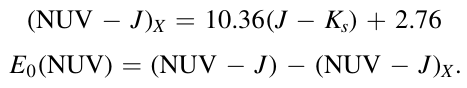

# Four Plots by Type

In [ ]:
int_Ez_nuv = np.array(Ez_nuv, dtype = int)
logP = np.log10(periods)

nones = np.zeros(len(gaia_data), dtype = bool)
valid_ez_nuv = (Ez_nuv > -100)

new_cmap = mplCol.ListedColormap(fun_3col['contrast_plt'])

def vsini_logP(ax, filts, x_axis = logP, y_axis = vsinis,
               symbols = ['v', 'P', 'X'], labels = ['a', 'b', 'c'], 
               sizes = [None, None, None], cmap = new_cmap,
               vmin = -2, vmax = 1,
               x_label = '$\log P_{VSX}$ (days)', y_label = '$vsini$ (km/s)',
               plt_lovar = False, xlog_scale = False, ylog_scale = True):
    
    cs = ax.scatter(x_axis[filts[0]], y_axis[filts[0]], 
                c= Ez_nuv[filts[0]], 
                    vmin = vmin, vmax=vmax, marker = symbols[0],
               label = labels[0], cmap = cmap, edgecolor= 'black', s = sizes[0])
    ax.scatter(x_axis[filts[1]], y_axis[filts[1]], c= Ez_nuv[filts[1]], 
               vmin = vmin, vmax=vmax, marker = symbols[1], label = labels[1],
              cmap = cmap, edgecolor= 'black' , s = sizes[1])
    ax.scatter(x_axis[filts[2]], y_axis[filts[2]], c= Ez_nuv[filts[2]], 
               vmin = vmin, vmax=vmax, marker = symbols[2], label = labels[2],
              s = sizes[2], cmap = cmap, edgecolor = 'black')
    
    if plt_lovar == True:
        ax.scatter(x_axis[low_rvs & valid_ez_nuv], y_axis[low_rvs & valid_ez_nuv], 
                   color = 'None', edgecolor = 'red', sizes = [120, 120, 120],
          label = 'low RV variables')

    ax.legend()
    if ylog_scale == True:
        ax.set_yscale('log')
    if xlog_scale == True:
        ax.set_xscale('log')
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    cb = fig.colorbar(cs, ax = ax)
    cb.set_label('$E_{\zeta}(NUV)$')

In [ ]:
horz_abs = ['right', 'left', 'right', 'left', 'right', 'left', 'left', 'left', 'left']
vert_abs = ['']


fig, ((ax, ax2), (ax3, ax4)) = plt.subplots(2,2, figsize=(10, 10))
ax.set_title('H-alpha')
vsini_logP(ax=ax, filts = [ha_emis, ha_abs, var_ha], 
           labels = ['Emission', 'Absorption', 'Variable H-alpha'], sizes = [80, 80, 70], plt_lovar = True)


for i in range(len(logP[ha_abs & valid_ez_nuv])):
    ax.text(logP[ha_abs & valid_ez_nuv][i], 
            vsinis[ha_abs & valid_ez_nuv][i], 
            gaia_data['star'][ha_abs & valid_ez_nuv][i], ha = horz_abs[i])

ax2.set_title('Li')
vsini_logP(ax=ax2, filts = [yes_li, no_li, nones],  symbols = ['*', 'o', None],
           labels = ['Li', 'No Li', None], sizes = [80, 80, None], plt_lovar = True)

ax3.set_title('Ca II H')
vsini_logP(ax=ax3, filts= [caH_emis, no_caH, var_caH], 
           symbols = ['^', 'o', 's'], 
           labels = ['Emission', 'None', 'Variable'], sizes = [80, 80, 70], plt_lovar = True)

ax4.set_title('Ca II K')
vsini_logP(ax=ax4, filts= [caK_emis, no_caK, var_caK], 
           symbols = ['^', 'o', 's'], labels = ['Emission', 'None', 'Variable'], 
           sizes = [80, 80, 70], plt_lovar = True)

fig.tight_layout()

In [ ]:

fig, ((ax, ax2), (ax3, ax4)) = plt.subplots(2,2, figsize=(10, 10))

ax.set_title('H-alpha')
vsini_logP(ax=ax, filts = [ha_emis, ha_abs, var_ha], 
           labels = ['Emission', 'Absorption', 'Variable H-alpha'], sizes = [80, 80, 70])


ax2.set_title('Li')
vsini_logP(ax=ax2, filts = [yes_li, no_li, nones],  symbols = ['*', 'o', None],
           labels = ['Li', 'No Li', None], sizes = [80, 80, None])

ax3.set_title('Ca II H')
vsini_logP(ax=ax3, filts= [caH_emis, no_caH, var_caH], 
           symbols = ['^', 'o', 's'], labels = ['Emission', 'None', 'Variable'], sizes = [80, 80, 70])


ax4.set_title('Ca II K')
vsini_logP(ax=ax4, filts= [caK_emis, no_caK, var_caK], 
           symbols = ['^', 'o', 's'], labels = ['Emission', 'None', 'Variable'], sizes = [80, 80, 70])


fig.tight_layout()

#Without colors

In [ ]:
x_vsinis = np.arange(1, 100, 0.1)
y_ez_nuv = -1.20*np.log10(x_vsinis) + 0.157
#Compare SSGs and RS CVn

In [ ]:
#color by NUV-J
def periods_ez_1(ax, cb_axis=nuv_j, vmin = 4, vmax = 10, cb_label = '$(NUV-J)_0$', cmap = 'PiYG'):
    cs = ax.scatter(logP, Ez_nuv, marker = '.', alpha = 1,
           c = cb_axis, cmap = cmap, vmin = vmin, vmax=vmax)
    ax.scatter(logP[fuv_nuv < 2], Ez_nuv[fuv_nuv < 2] ,marker = '*', alpha = 1,
           c =cb_axis[fuv_nuv < 2], label='UV Excess', 
               vmin=vmin, vmax=vmax, s=100, edgecolor = 'black', cmap = cmap)
    cb = fig.colorbar(cs, ax = ax)
    cb.set_label(cb_label)
    
    
    #ax.plot(logP[ha_abs], Ez_nuv[ha_abs], marker='P', linestyle='none', 
           # alpha=0.5, color = abs_color, label = 'Absorption')
    #ax.plot(logP[ha_emis], Ez_nuv[ha_emis], marker='v', linestyle='none', 
            #alpha=0.5, color = emis_color, label = 'Emission')
    #ax.plot(logP[var_ha], Ez_nuv[var_ha], marker='X', linestyle='none', 
           # alpha=0.5, color = var_color, label = 'Variable H-alpha')  
    #ax.plot(x_vsinis, y_ez_nuv, ls ='--', 
            #label='Equation 6 (Dixon 2025)', color = 'black')
    
   # ax.set_xscale('log')

    ax.set_xlabel('$\log P_{VSX}$')
    ax.set_ylabel('$E_{\zeta}(NUV)$')
    
fig, ax = plt.subplots(1, 1, figsize=(6,6))
ax.axvline(np.log10(2), ls = '--', color ='red')
periods_ez_1(ax=ax)
ax.set_xlim(left=0)
ax.set_ylim(2,-6)
ax.legend()

In [ ]:
fig, ax = plt.subplots(1, figsize=(7,6))
ax.axvline(np.log10(2), ls = '--', color ='red')
periods_ez_1(ax=ax, cb_axis = M_G, cmap = 'viridis', vmin = 0, vmax=5, cb_label = '$M_G$')
'''
cs = ax.scatter(logP, Ez_nuv, marker = '.', alpha = 1,
c = M_G, cmap = 'viridis', vmin = 0, vmax=5)

ax.scatter(logP[fuv_nuv < 2], Ez_nuv[fuv_nuv < 2] ,marker = '*', alpha = 1,
           c =M_G[fuv_nuv < 2], label='UV Excess', 
           vmin=0, vmax=5, s=100, edgecolor = 'black', cmap = 'viridis')
cb = fig.colorbar(cs, ax = ax)
ax.set_xlabel('$\log P_{VSX}$')
ax.set_ylabel('$E_{\zeta}(NUV)$')
cb.set_label('$M_G$')
'''
ax.set_xlim(left=0)
ax.set_ylim(2,-6)
ax.legend()


outliers = ((fuv_nuv < 2) & (Ez_nuv < -3.5) & (Ez_nuv > -6))
for i in range(len(M_G[outliers])):
    ax.text(logP[outliers][i], Ez_nuv[outliers][i], gaia_data['star'][outliers][i])
print(gaia_data['star'][(fuv_nuv < 2) & (Ez_nuv < -3.5)])

In [ ]:
min(periods)

In [ ]:
abs_color = 'darkmagenta'
emis_color = 'green'
var_color = 'darkcyan'

fig, (ax, ax2) = plt.subplots(2, 1)
#ax.scatter(fuv_nuv, bp_rp, s = 7, alpha = 0.3, color = 'gray')
def vsini_ez_1(ax):
    ax.plot(vsinis[ha_abs], Ez_nuv[ha_abs], marker='P', linestyle='none', 
            alpha=0.5, color = abs_color, label = 'Absorption')
    ax.plot(vsinis[ha_emis], Ez_nuv[ha_emis], marker='v', linestyle='none', 
            alpha=0.5, color = emis_color, label = 'Emission')
    ax.plot(vsinis[var_ha], Ez_nuv[var_ha], marker='X', linestyle='none', 
            alpha=0.5, color = var_color, label = 'Variable H-alpha')
    ax.scatter(vsinis[low_rvs], Ez_nuv[low_rvs], color = 'None', edgecolor = 'red', sizes = [90,90,90],
          label = 'Low RV Variables')
    
    ax.plot(x_vsinis, y_ez_nuv, ls ='--', 
            label='Equation 6 (Dixon 2025)', color = 'black')
    ax.set_xscale('log')

    ax.set_xlabel('$vsini$ (km/s)')
    ax.set_ylabel('$E_{\zeta}(NUV)$')
    
vsini_ez_1(ax=ax)
ax.set_ylim(0, -4)
vsini_ez_1(ax=ax2)

ax2.legend()

fig.tight_layout()

#Change

In [ ]:
print(gaia_data['star', 'mh_gspphot'][Ez_nuv > 5])
#None 

In [ ]:
print()

In [ ]:
print(j_mag[Ez_nuv > 5])
print(k_mag[Ez_nuv > 5]) #ER Lyn Double Check magnitudes ALLWISE

In [ ]:
def vsini_ez(ax, filts, symbols= ['v', 'P', 'X'], 
               colors = [None, None, None], labels = ['a', 'b', 'c'], size = [10, 10,10], dixon_lw = 2):
    ax.plot(vsinis[filts[0]], Ez_nuv[filts[0]], marker= symbols[0], 
            linestyle='none', alpha=0.5, color = colors[0], 
            label = labels[0], ms = size[0])
    ax.plot(vsinis[filts[1]], Ez_nuv[filts[1]], marker= symbols[1], 
            linestyle='none', alpha=0.5, color = colors[1], 
            label = labels[1], ms = size[1])
    ax.plot(vsinis[filts[2]], Ez_nuv[filts[2]], marker= symbols[2], 
            linestyle='none', alpha=0.5, color = colors[2], 
            label = labels[2],ms = size[2])
    ax.plot(x_vsinis, y_ez_nuv, ls ='--', 
            label='Equation 6 (Dixon 2025)', color = 'black', lw = dixon_lw)
    ax.set_xscale('log')

    ax.set_xlabel('$vsini$ (km/s)')
    ax.set_ylabel('$E_{\zeta}(NUV)$')
    ax.legend()
    ax.set_ylim(0, -4)

In [ ]:
fig, ((ax, ax2), (ax3, ax4)) = plt.subplots(2,2, figsize=(8, 10))
ax.set_title('H-alpha')
vsini_ez(ax=ax, filts = [ha_emis, ha_abs, var_ha], 
           labels = ['Emission', 'Absorption', 'Variable H-alpha'],
        colors = ['green', 'darkmagenta', 'darkcyan'])

ax2.set_title('Li')
vsini_ez(ax=ax2, filts = [yes_li, no_li, nones],  symbols = ['*', 'o', None],
           labels = ['Li', 'No Li', None],
        colors = ['#04a2a2', '#fe4e5e', None], size = [10, 10, None], dixon_lw = 2)
ax3.set_title('Ca II H')
vsini_ez(ax=ax3, filts= [caH_emis, no_caH, var_caH], 
           symbols = ['^', 'o', 's'], 
         labels = ['Emission', 'None', 'Variable'],
        colors = ['#cc8300', '#b043e7', '#0bcecd'])

ax4.set_title('Ca II K')
vsini_ez(ax=ax4, filts= [caK_emis, no_caK, var_caK], 
           symbols = ['^', 'o', 's'], 
         labels = ['Emission', 'None', 'Variable'],
        colors = ['#cc8300', '#b043e7', '#0bcecd'])

fig.tight_layout()

In [ ]:
fig, ((ax, ax2), (ax3, ax4)) = plt.subplots(2,2, figsize=(8, 10))
ax.set_title('H-alpha')
vsini_ez(ax=ax, filts = [ha_emis, ha_abs, var_ha], 
           labels = ['Emission', 'Absorption', 'Variable H-alpha'],
        colors = ['green', 'darkmagenta', 'darkcyan'])
ax.scatter(vsinis[low_rvs], Ez_nuv[low_rvs], color = 'None', edgecolor = 'red', sizes = [150,150,150],
          label = 'Low RV Variables')
ax.legend()

ax2.set_title('Li')
vsini_ez(ax=ax2, filts = [yes_li, no_li, nones],  symbols = ['*', 'o', None],
           labels = ['Li', 'No Li', None],
        colors = ['#04a2a2', '#fe4e5e', None], size = [10, 10, None])
ax2.scatter(vsinis[low_rvs], Ez_nuv[low_rvs], color = 'None', edgecolor = 'red', sizes = [150,150,150])
ax3.set_title('Ca II H')
vsini_ez(ax=ax3, filts= [caH_emis, no_caH, var_caH], 
           symbols = ['^', 'o', 's'], 
         labels = ['Emission', 'None', 'Variable'],
        colors = ['#cc8300', '#b043e7', '#0bcecd'])
ax3.scatter(vsinis[low_rvs], Ez_nuv[low_rvs], color = 'None', edgecolor = 'red', sizes = [150,150,150])

ax4.set_title('Ca II K')
vsini_ez(ax=ax4, filts= [caK_emis, no_caK, var_caK], 
           symbols = ['^', 'o', 's'], 
         labels = ['Emission', 'None', 'Variable'],
        colors = ['#cc8300', '#b043e7', '#0bcecd'])
ax4.scatter(vsinis[low_rvs], Ez_nuv[low_rvs], color = 'None', edgecolor = 'red', sizes = [150,150,150])

fig.tight_layout()

# Four Data
copy from Figure 4 in Dixon 2025

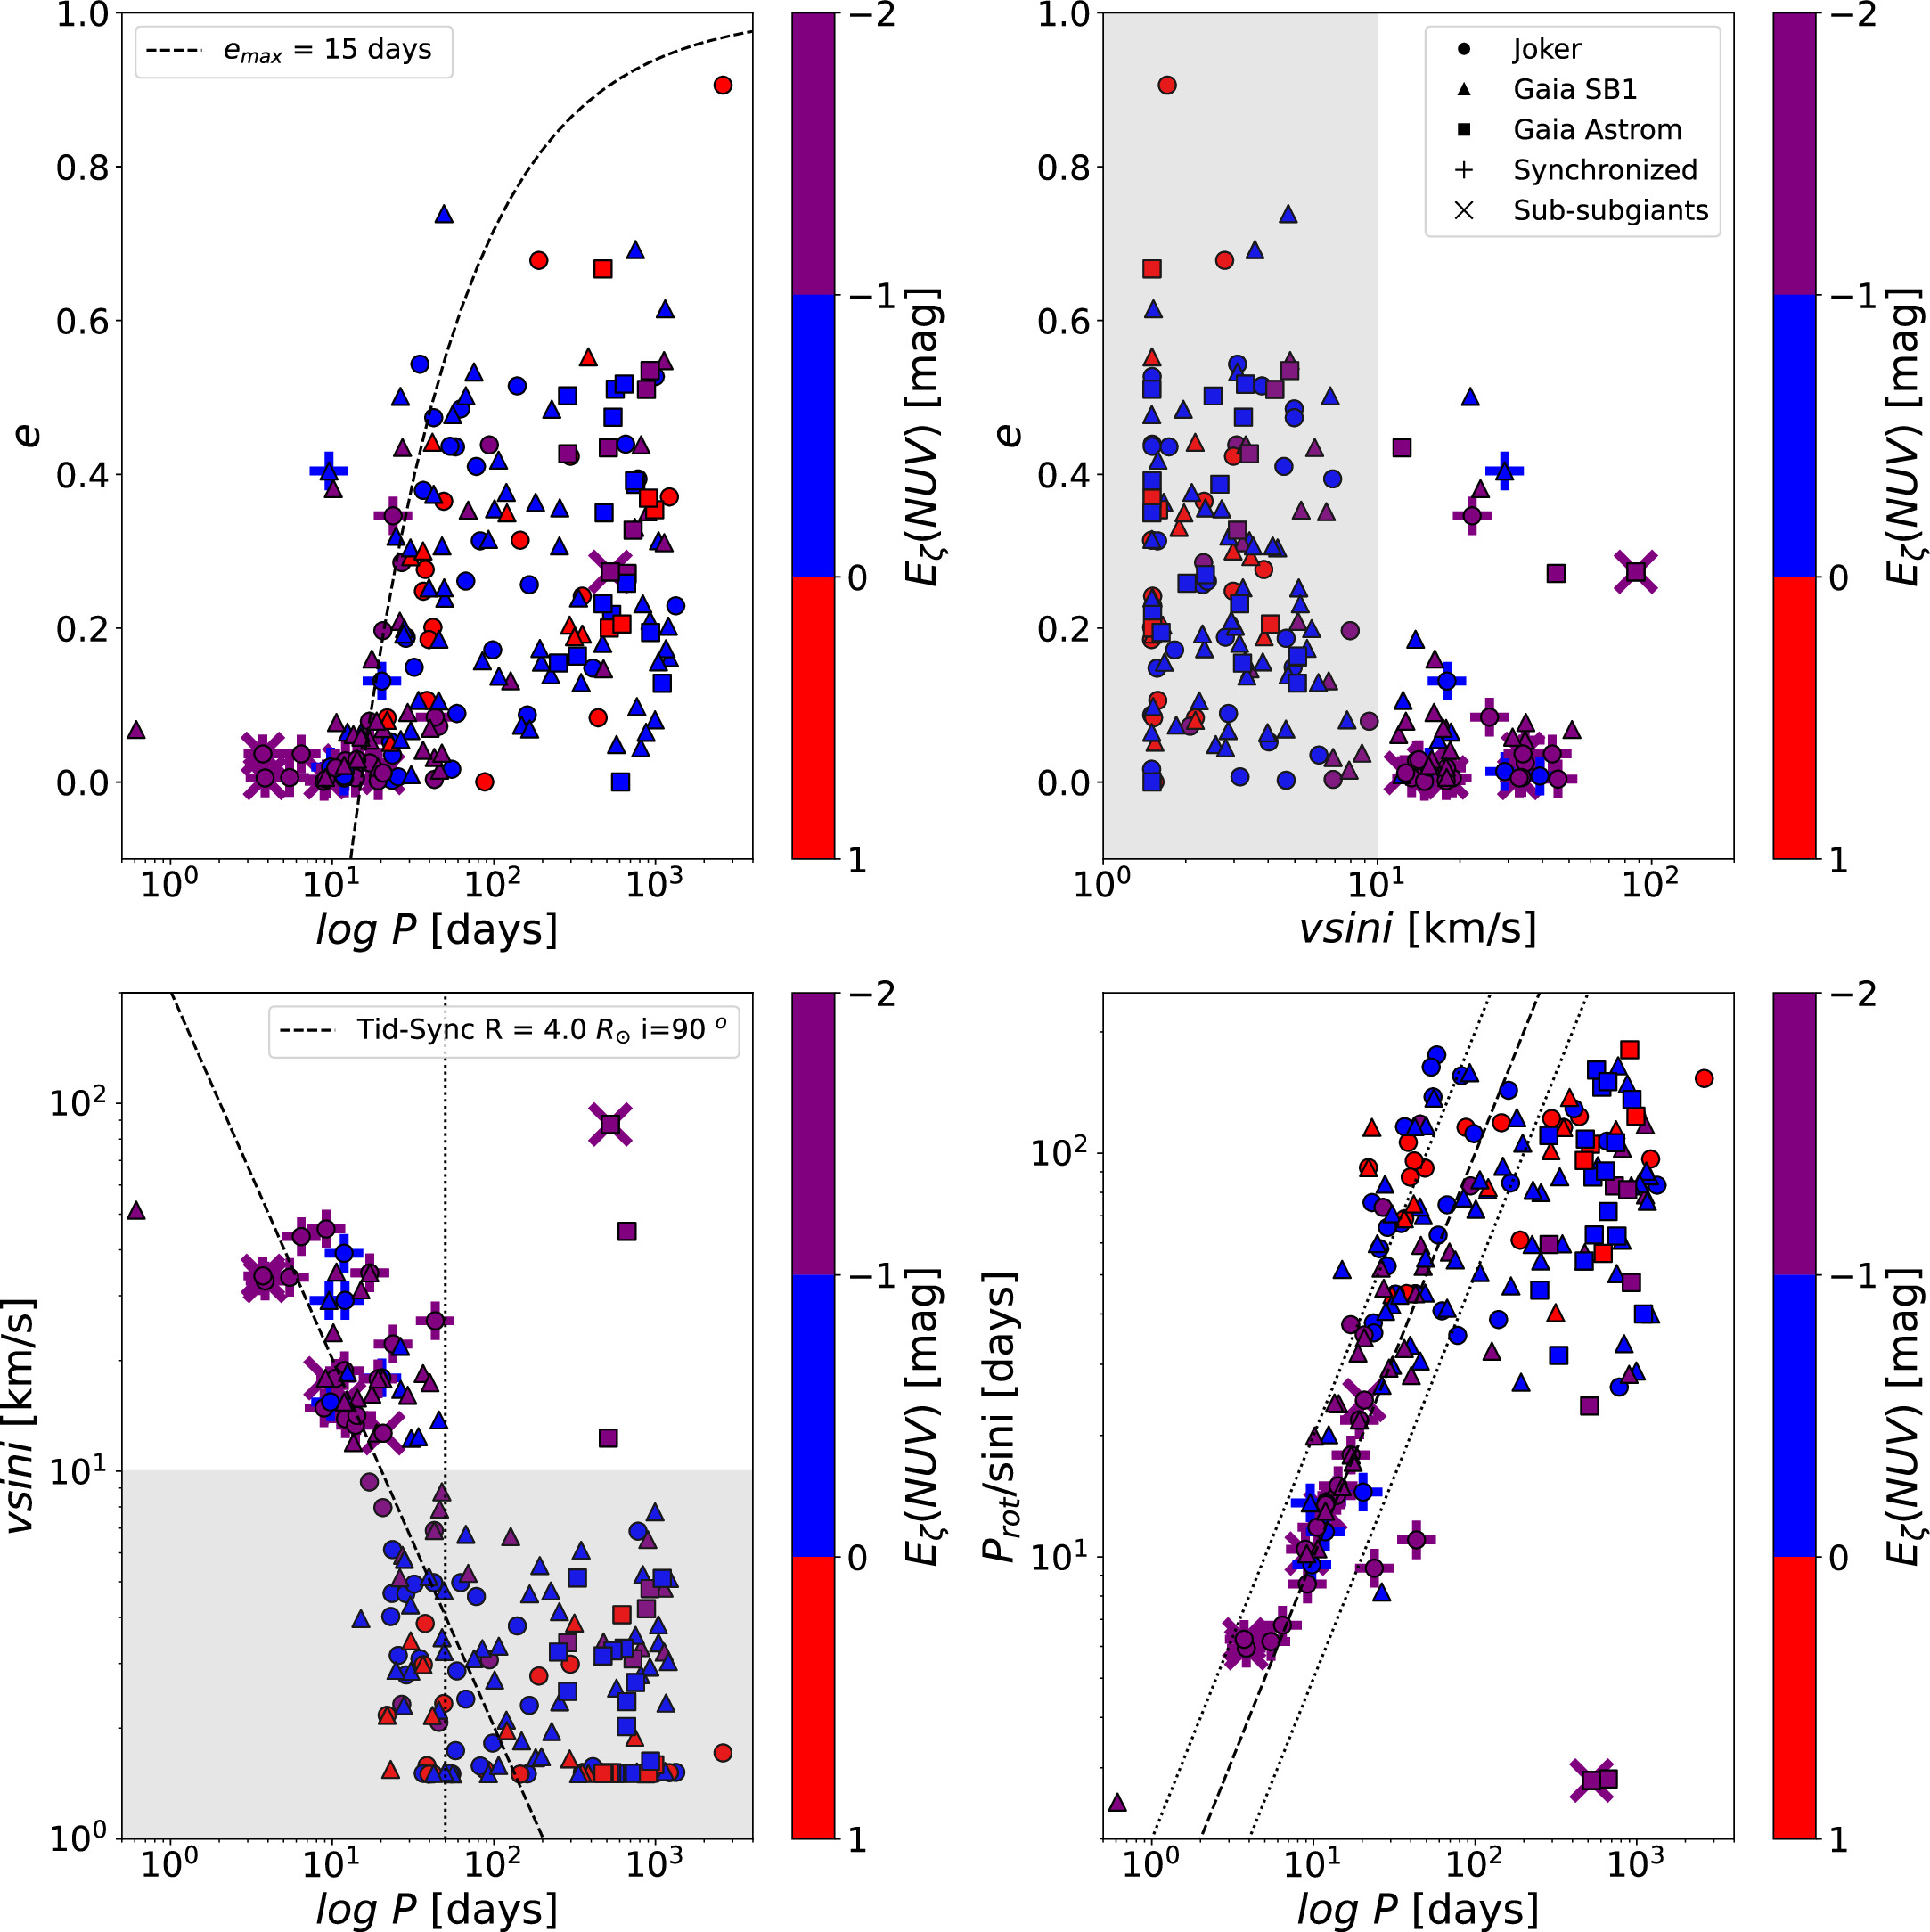

In [ ]:
print(orb_dat.columns.to_list())

In [ ]:
orb_ids = np.array(orb_dat['source_id'], dtype = np.int64) #gaia ids 

#eccentricites
eccen = np.array([orb_dat['ecc'][list(orb_ids).index(item)] if item in orb_ids 
                  else np.nan for item in gaia_data['source_id']])
#orbital period
orb_period = np.array([orb_dat['P_orb'][list(orb_ids).index(item)] if item in orb_ids 
                  else np.nan for item in gaia_data['source_id']])

print(100 * eccen)

In [ ]:
ideal_logP = np.arange(0,1000,0.1)

def four_plot_dixon(title, filts, symbols = ['v', 'P', 'X'], labels = ['a', 'b', 'c'], 
               sizes = [None, None, None], cmap = new_cmap, plt_lovar = False):
    '''
    imitates plots Dixon et. al 2025
    --------------------------------------------------
    inputs:
        title ('str') - the title of the figure
        
        filts (list of three boolean array) - filters that show three distinct populations (
        (i.e. Emission, Variable H-alpha, Absorption). Format as [filter1, filter2, filter3]
        
        symbols (str tuple, array or list) - matplotlib symbols. For example: ['*', 'o', 's']
        for (star, circle, square). 
        
        labels (str list/array/tuple) - labels for three distinct population. Should follow the formula 
        ['a', 'b', 'c']
        
        sizes (int/float array/list/tuple of 3) - size of points.
        
        cmap ('str' or )
    
    '''
    fig, ((ax, ax2), (ax3, ax4)) = plt.subplots(2,2, figsize=(10, 10))
    fig.suptitle(title)
    vsini_logP(ax = ax, filts = filts, x_axis = orb_period, y_axis = eccen,
               symbols = symbols, labels = labels, 
               sizes = sizes, cmap = cmap, plt_lovar = plt_lovar, 
               x_label = '$P_{orb}$', y_label = 'e', xlog_scale = True, ylog_scale = False)
    
    ax.set_xlim(1,1000)
    ax.set_ylim(-0.2,1)
    
    ax2.axvspan(0, 10, color = 'grey', alpha = 0.5)
    vsini_logP(ax = ax2, filts = filts, x_axis = vsinis, y_axis = eccen,
               symbols = symbols, labels = symbols, 
               sizes = sizes, cmap = cmap, plt_lovar = plt_lovar,
              x_label = 'vsini', y_label = 'e', xlog_scale = True, ylog_scale = False)
    ax2.get_legend().remove()
    ax2.set_xlim(1,10**2.5)
    ax2.set_ylim(-0.2,1)
    
    ax3.axhspan(0, 10, color ='grey', alpha = 0.5)
    ax3.axvline(50, ls = ':', color = 'black')
    vsini_logP(ax = ax3, filts = filts, x_axis = orb_period, y_axis = vsinis,
               symbols = symbols, labels = symbols, 
               sizes = sizes, cmap = new_cmap, plt_lovar = plt_lovar,
               x_label = '$P_{orb}$', xlog_scale = True, ylog_scale = True)
    
    ax3.get_legend().remove()
    ax3.set_xlim(1,1000)
    ax3.set_ylim(1,10**2.5)
    
    vsini_logP(ax = ax4, filts = filts, x_axis = orb_period, y_axis = periods/vsinis,
               symbols = symbols, labels = symbols, 
               sizes = sizes, cmap = cmap, plt_lovar = plt_lovar,
              x_label = '$P_{orb}$', y_label = r'$P_{VSX}/vsini$',
              xlog_scale = True, ylog_scale = True)
    #ax4.plot(ideal_logP, ideal_logP, ls = '--')
    ax4.get_legend().remove()
    ax4.set_xlim(1,1000)
    ax4.set_xlim(1,10**2.5)
    
    fig.tight_layout()
    return fig, ((ax, ax2), (ax3, ax4))

In [ ]:
#new_cmap3 = mplCol.ListedColormap(fun_3col['bi'])

fig, axes = four_plot_dixon(title= 'H-alpha', filts = [ha_emis, ha_abs, var_ha], 
           labels = ['Emission', 'Absorption', 'Variable H-alpha'], sizes = [80, 80, 70])

In [ ]:
fig, axes = four_plot_dixon(title='Li', filts = [yes_li, no_li, nones],  symbols = ['*', 'o', None],
           labels = ['Li', 'No Li', None], sizes = [80, 80, None])

In [ ]:
fig, ax = four_plot_dixon(title = 'Ca II H', filts= [caH_emis, no_caH, var_caH], 
           symbols = ['^', 'o', 's'], labels = ['Emission', 'None', 'Variable'], sizes = [80, 80, 70])


In [ ]:
fig, ax = four_plot_dixon(title = 'Ca II K', filts= [caK_emis, no_caK, var_caK], 
           symbols = ['^', 'o', 's'], labels = ['Emission', 'None', 'Variable'], sizes = [80, 80, 70])